# Evaluate mutation predictions in single-cell data from 3 ML model types

Andrew Ashford, Pathways + Omics Group - OHSU, 5/31/2024

This Jupyter Notebook will be used to evaluate the single-cell mutation predictions that were predicted/saved using the "code_test_notebook_2.ipynb" notebook file.


#### Import modules

In [30]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import csv
from scipy.stats import spearmanr


#### Specify file locations and load in

In [31]:
# Specify the location of the AnnData object file saved with all the predictions
scrna_preds_file_loc = '/home/groups/precepts/ashforda/scOPE_github_stuff/trained_models/integrated_adata_with_predictions.h5ad'


In [32]:
# Load scRNA predictions AnnData object in using the ScanPy module
scrna_preds_adata = sc.read_h5ad(scrna_preds_file_loc)


In [33]:
# Sanity check
print(scrna_preds_adata)


AnnData object with n_obs × n_vars = 20362 × 5668
    obs: 'dataset', 'leiden', 'cell_type', 'ridge_preds_TET2', 'rf_preds_TET2', 'svm_preds_TET2', 'ridge_preds_NPM1', 'rf_preds_NPM1', 'svm_preds_NPM1', 'ridge_preds_WT1', 'rf_preds_WT1', 'svm_preds_WT1', 'ridge_preds_DNMT3A', 'rf_preds_DNMT3A', 'svm_preds_DNMT3A', 'ridge_preds_SRSF2', 'rf_preds_SRSF2', 'svm_preds_SRSF2', 'ridge_preds_KRAS', 'rf_preds_KRAS', 'svm_preds_KRAS', 'ridge_preds_IDH2', 'rf_preds_IDH2', 'svm_preds_IDH2', 'ridge_preds_BCOR', 'rf_preds_BCOR', 'svm_preds_BCOR', 'ridge_preds_FLT3', 'rf_preds_FLT3', 'svm_preds_FLT3', 'ridge_preds_CEBPA', 'rf_preds_CEBPA', 'svm_preds_CEBPA', 'ridge_preds_SF3B1', 'rf_preds_SF3B1', 'svm_preds_SF3B1', 'ridge_preds_RUNX1', 'rf_preds_RUNX1', 'svm_preds_RUNX1', 'ridge_preds_IDH1', 'rf_preds_IDH1', 'svm_preds_IDH1', 'ridge_preds_PHF6', 'rf_preds_PHF6', 'svm_preds_PHF6', 'ridge_preds_NF1', 'rf_preds_NF1', 'svm_preds_NF1', 'ridge_preds_JAK2', 'rf_preds_JAK2', 'svm_preds_JAK2', 'ridge_preds_NR

In [34]:
# Specify the location of the ROC AUC csv file
roc_auc_file_loc = '/home/groups/precepts/ashforda/scOPE_github_stuff/trained_models/roc_auc_dict_to_file.csv'


In [35]:
# Read in the ROC AUC csv file into dataframe
roc_auc_df = pd.read_csv(roc_auc_file_loc)


In [36]:
# Display the DataFrame to verify its content
print(roc_auc_df)


      key                    subkey   value_1
0    TET2          Ridge Classifier  0.744097
1    TET2  Random Forest Classifier  0.700347
2    TET2            SVM Classifier  0.748785
3    NPM1          Ridge Classifier  0.971327
4    NPM1  Random Forest Classifier  0.955085
..    ...                       ...       ...
97    CBL  Random Forest Classifier  0.550000
98    CBL            SVM Classifier  0.850000
99   SMC3          Ridge Classifier  0.700000
100  SMC3  Random Forest Classifier  0.700000
101  SMC3            SVM Classifier  0.700000

[102 rows x 3 columns]


In [37]:
print(roc_auc_df[roc_auc_df['subkey'] == 'Ridge Classifier'])


       key            subkey   value_1
0     TET2  Ridge Classifier  0.744097
3     NPM1  Ridge Classifier  0.971327
6      WT1  Ridge Classifier  0.835000
9   DNMT3A  Ridge Classifier  0.769623
12   SRSF2  Ridge Classifier  0.842857
15    KRAS  Ridge Classifier  0.819444
18    IDH2  Ridge Classifier  0.723469
21    BCOR  Ridge Classifier  0.694444
24    FLT3  Ridge Classifier  0.623810
27   CEBPA  Ridge Classifier  0.695833
30   SF3B1  Ridge Classifier  0.775000
33   RUNX1  Ridge Classifier  0.887500
36    IDH1  Ridge Classifier  0.761000
39    PHF6  Ridge Classifier  0.683333
42     NF1  Ridge Classifier  0.650000
45    JAK2  Ridge Classifier  0.750000
48    NRAS  Ridge Classifier  0.646778
51   CCND3  Ridge Classifier  0.700000
54   RAD21  Ridge Classifier  0.750000
57   ASXL1  Ridge Classifier  0.739683
60  CREBBP  Ridge Classifier  0.400000
63  BCORL1  Ridge Classifier  0.750000
66    EZH2  Ridge Classifier  0.700000
69   STAG2  Ridge Classifier  0.666250
72  PTPN11  Ridge Classif

In [38]:
print(roc_auc_df[roc_auc_df['subkey'] == 'Random Forest Classifier'])


        key                    subkey   value_1
1      TET2  Random Forest Classifier  0.700347
4      NPM1  Random Forest Classifier  0.955085
7       WT1  Random Forest Classifier  0.660000
10   DNMT3A  Random Forest Classifier  0.750216
13    SRSF2  Random Forest Classifier  0.804209
16     KRAS  Random Forest Classifier  0.616667
19     IDH2  Random Forest Classifier  0.661607
22     BCOR  Random Forest Classifier  0.597222
25     FLT3  Random Forest Classifier  0.655782
28    CEBPA  Random Forest Classifier  0.720833
31    SF3B1  Random Forest Classifier  0.662500
34    RUNX1  Random Forest Classifier  0.787500
37     IDH1  Random Forest Classifier  0.678500
40     PHF6  Random Forest Classifier  0.737500
43      NF1  Random Forest Classifier  0.400000
46     JAK2  Random Forest Classifier  0.787500
49     NRAS  Random Forest Classifier  0.698111
52    CCND3  Random Forest Classifier  0.600000
55    RAD21  Random Forest Classifier  0.775000
58    ASXL1  Random Forest Classifier  0

In [39]:
print(roc_auc_df[roc_auc_df['subkey'] == 'SVM Classifier'])


        key          subkey   value_1
2      TET2  SVM Classifier  0.748785
5      NPM1  SVM Classifier  0.956327
8       WT1  SVM Classifier  0.814000
11   DNMT3A  SVM Classifier  0.757261
14    SRSF2  SVM Classifier  0.847449
17     KRAS  SVM Classifier  0.669444
20     IDH2  SVM Classifier  0.719388
23     BCOR  SVM Classifier  0.697222
26     FLT3  SVM Classifier  0.593537
29    CEBPA  SVM Classifier  0.722917
32    SF3B1  SVM Classifier  0.750000
35    RUNX1  SVM Classifier  0.889286
38     IDH1  SVM Classifier  0.735000
41     PHF6  SVM Classifier  0.575000
44      NF1  SVM Classifier  0.650000
47     JAK2  SVM Classifier  0.675000
50     NRAS  SVM Classifier  0.653111
53    CCND3  SVM Classifier  0.700000
56    RAD21  SVM Classifier  0.700000
59    ASXL1  SVM Classifier  0.757143
62   CREBBP  SVM Classifier  0.600000
65   BCORL1  SVM Classifier  0.750000
68     EZH2  SVM Classifier  0.650000
71    STAG2  SVM Classifier  0.656250
74   PTPN11  SVM Classifier  0.702778
77    U2AF1 

#### Calculate scores using the ROC AUC and predictions

In [40]:
# Original code to calculate the P1 scores
'''
cur_gene = tuple(cur_gene)[0]
base_mtype = MuType({('Gene', cur_gene): None})
pred_vals = {mtype: pred_data.loc[mtype].apply(np.mean)
             for mtype in auc_vec.index}
corr_vals = {mtype: spearmanr(pred_vals[base_mtype], vals)[0]
             for mtype, vals in pred_vals.items() if mtype != base_mtype}
divg_scrs = pd.Series({mtype: (1 - corr_val) * (auc_vec[mtype] - 0.7)
                       for mtype, corr_val in corr_vals.items()})
best_subtype = divg_scrs.sort_values().index[-1]
'''


"\ncur_gene = tuple(cur_gene)[0]\nbase_mtype = MuType({('Gene', cur_gene): None})\npred_vals = {mtype: pred_data.loc[mtype].apply(np.mean)\n             for mtype in auc_vec.index}\ncorr_vals = {mtype: spearmanr(pred_vals[base_mtype], vals)[0]\n             for mtype, vals in pred_vals.items() if mtype != base_mtype}\ndivg_scrs = pd.Series({mtype: (1 - corr_val) * (auc_vec[mtype] - 0.7)\n                       for mtype, corr_val in corr_vals.items()})\nbest_subtype = divg_scrs.sort_values().index[-1]\n"

In [41]:
mutation_types = list(set(roc_auc_df['key']))
print(mutation_types)


['IDH1', 'CEBPA', 'IDH2', 'BCOR', 'EZH2', 'NRAS', 'CBL', 'RUNX1', 'FLT3', 'TP53', 'PDS5B', 'WT1', 'NPM1', 'KIT', 'JAK2', 'CCND3', 'U2AF1', 'RAD21', 'NF1', 'CREBBP', 'PTPN11', 'SRSF2', 'ZRSR2', 'TET2', 'BCORL1', 'PHF6', 'SMC3', 'ASXL1', 'DNMT3A', 'STAG2', 'SF3B1', 'KRAS', 'GATA2', 'SMC1A']


In [42]:
# Function to get ROC AUC scores for a specified classifier
def get_roc_auc(roc_auc_df, classifier):
    auc_dict = {}
    classifier_df = roc_auc_df[roc_auc_df['subkey'] == classifier]
    for mutation in mutation_types:
        auc_score = classifier_df[classifier_df['key'] == mutation]['value_1']
        if not auc_score.empty:
            auc_dict[mutation] = auc_score.values[0]
    return auc_dict


In [43]:
# User can specify which classifier to use
selected_classifier = 'Ridge Classifier'  # Change this to the desired classifier

# Get ROC AUC scores for the specified classifier
auc_vec = get_roc_auc(roc_auc_df, selected_classifier)


In [44]:
print(auc_vec)


{'IDH1': 0.7610000000000001, 'CEBPA': 0.6958333333333333, 'IDH2': 0.7234693877551021, 'BCOR': 0.6944444444444444, 'EZH2': 0.7, 'NRAS': 0.6467777777777777, 'CBL': 0.65, 'RUNX1': 0.8875, 'FLT3': 0.6238095238095237, 'TP53': 0.8861111111111113, 'PDS5B': 0.675, 'WT1': 0.8350000000000002, 'NPM1': 0.9713265306122448, 'KIT': 0.575, 'JAK2': 0.75, 'CCND3': 0.7, 'U2AF1': 0.7305555555555555, 'RAD21': 0.75, 'NF1': 0.65, 'CREBBP': 0.4, 'PTPN11': 0.6361111111111112, 'SRSF2': 0.8428571428571429, 'ZRSR2': 0.8, 'TET2': 0.7440972222222222, 'BCORL1': 0.75, 'PHF6': 0.6833333333333333, 'SMC3': 0.7, 'ASXL1': 0.7396825396825397, 'DNMT3A': 0.7696232339089482, 'STAG2': 0.66625, 'SF3B1': 0.7749999999999999, 'KRAS': 0.8194444444444444, 'GATA2': 0.7666666666666668, 'SMC1A': 0.4}


In [45]:
# Calculate Spearman correlation with base mutation type 'TET2'
base_preds = scrna_preds_adata.obs[f'ridge_preds_NPM1']
corr_vals = {}
for mutation in mutation_types:
    if mutation != 'NPM1':
        current_preds = scrna_preds_adata.obs[f'ridge_preds_{mutation}']
        corr_vals[mutation] = spearmanr(base_preds, current_preds)[0]


/tmp/ipykernel_36370/1897043823.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_vals[mutation] = spearmanr(base_preds, current_preds)[0]


In [46]:
print(corr_vals)


{'IDH1': 0.11111789755201606, 'CEBPA': -0.037494516444120995, 'IDH2': 0.04120868539536623, 'BCOR': 0.025628766701117706, 'EZH2': -0.04854627622347124, 'NRAS': 0.019298916444429156, 'CBL': nan, 'RUNX1': -0.06334019956638329, 'FLT3': 0.06621157096379497, 'TP53': -0.0320114465746425, 'PDS5B': -0.006907579143454837, 'WT1': -0.06818924396188787, 'KIT': 0.020112343702056272, 'JAK2': nan, 'CCND3': 0.012597267076141038, 'U2AF1': -0.13638683852459904, 'RAD21': 0.037851067767579634, 'NF1': -0.0022988680342408726, 'CREBBP': -0.03060272919509839, 'PTPN11': 0.025065433080724314, 'SRSF2': -0.09489455586905789, 'ZRSR2': -0.006298884927333167, 'TET2': 0.01266258373155842, 'BCORL1': -0.02081043418675936, 'PHF6': 0.010974258359859915, 'SMC3': nan, 'ASXL1': -0.019282403568559793, 'DNMT3A': 0.33711515430231337, 'STAG2': -0.16123942720528034, 'SF3B1': 0.003912190766728395, 'KRAS': -0.05790962377483075, 'GATA2': 0.00854755206682279, 'SMC1A': nan}


In [47]:
# Calculate divergence scores
divg_scrs = {}
for mutation, auc_score in auc_vec.items():
    if mutation != 'NPM1':
        corr_val = corr_vals[mutation]
        divg_scrs[mutation] = (1 - corr_val) * (auc_score - 0.7)
        

In [48]:
print(divg_scrs)


{'IDH1': 0.054221808249327166, 'CEBPA': -0.0043228938185171555, 'IDH2': 0.022502245138680238, 'BCOR': -0.005413173518327105, 'EZH2': 0.0, 'NRAS': -0.05219509100256877, 'CBL': nan, 'RUNX1': 0.1993762874186969, 'FLT3': -0.0711457850694252, 'TP53': 0.192068797001392, 'PDS5B': -0.02517268947858628, 'WT1': 0.1442055479348551, 'KIT': -0.12248595703724297, 'JAK2': nan, 'CCND3': 0.0, 'U2AF1': 0.03472293117714053, 'RAD21': 0.048107446611621064, 'NF1': -0.05011494340171198, 'CREBBP': -0.30918081875852943, 'PTPN11': -0.0622874862198425, 'SRSF2': 0.15641350798129405, 'ZRSR2': 0.1006298884927334, 'TET2': 0.0435388374535042, 'BCORL1': 0.05104052170933802, 'PHF6': -0.016483762360668945, 'SMC3': nan, 'ASXL1': 0.04044771442732388, 'DNMT3A': 0.04615218666670707, 'STAG2': -0.03919183066817815, 'SF3B1': 0.07470658569249532, 'KRAS': 0.1263614272842159, 'GATA2': 0.06609682986221202, 'SMC1A': nan}


In [49]:
divg_scrs_df = pd.DataFrame.from_dict(divg_scrs, orient='index', columns=['divergence_score'])
best_mutation = divg_scrs_df['divergence_score'].idxmax()


In [50]:
# Print results for verification
print(f"ROC AUC scores for {selected_classifier}:")
print(auc_vec)

print("Spearman correlation values with base mutation type (TET2):")
print(corr_vals)

print("Divergence scores for each mutation type:")
print(divg_scrs_df)

print(f"Best mutation type identified: {best_mutation}")


ROC AUC scores for Ridge Classifier:
{'IDH1': 0.7610000000000001, 'CEBPA': 0.6958333333333333, 'IDH2': 0.7234693877551021, 'BCOR': 0.6944444444444444, 'EZH2': 0.7, 'NRAS': 0.6467777777777777, 'CBL': 0.65, 'RUNX1': 0.8875, 'FLT3': 0.6238095238095237, 'TP53': 0.8861111111111113, 'PDS5B': 0.675, 'WT1': 0.8350000000000002, 'NPM1': 0.9713265306122448, 'KIT': 0.575, 'JAK2': 0.75, 'CCND3': 0.7, 'U2AF1': 0.7305555555555555, 'RAD21': 0.75, 'NF1': 0.65, 'CREBBP': 0.4, 'PTPN11': 0.6361111111111112, 'SRSF2': 0.8428571428571429, 'ZRSR2': 0.8, 'TET2': 0.7440972222222222, 'BCORL1': 0.75, 'PHF6': 0.6833333333333333, 'SMC3': 0.7, 'ASXL1': 0.7396825396825397, 'DNMT3A': 0.7696232339089482, 'STAG2': 0.66625, 'SF3B1': 0.7749999999999999, 'KRAS': 0.8194444444444444, 'GATA2': 0.7666666666666668, 'SMC1A': 0.4}
Spearman correlation values with base mutation type (TET2):
{'IDH1': 0.11111789755201606, 'CEBPA': -0.037494516444120995, 'IDH2': 0.04120868539536623, 'BCOR': 0.025628766701117706, 'EZH2': -0.0485462762

#### Just explore the mutation preds

In [51]:
# Sanity check
print(scrna_preds_adata)


AnnData object with n_obs × n_vars = 20362 × 5668
    obs: 'dataset', 'leiden', 'cell_type', 'ridge_preds_TET2', 'rf_preds_TET2', 'svm_preds_TET2', 'ridge_preds_NPM1', 'rf_preds_NPM1', 'svm_preds_NPM1', 'ridge_preds_WT1', 'rf_preds_WT1', 'svm_preds_WT1', 'ridge_preds_DNMT3A', 'rf_preds_DNMT3A', 'svm_preds_DNMT3A', 'ridge_preds_SRSF2', 'rf_preds_SRSF2', 'svm_preds_SRSF2', 'ridge_preds_KRAS', 'rf_preds_KRAS', 'svm_preds_KRAS', 'ridge_preds_IDH2', 'rf_preds_IDH2', 'svm_preds_IDH2', 'ridge_preds_BCOR', 'rf_preds_BCOR', 'svm_preds_BCOR', 'ridge_preds_FLT3', 'rf_preds_FLT3', 'svm_preds_FLT3', 'ridge_preds_CEBPA', 'rf_preds_CEBPA', 'svm_preds_CEBPA', 'ridge_preds_SF3B1', 'rf_preds_SF3B1', 'svm_preds_SF3B1', 'ridge_preds_RUNX1', 'rf_preds_RUNX1', 'svm_preds_RUNX1', 'ridge_preds_IDH1', 'rf_preds_IDH1', 'svm_preds_IDH1', 'ridge_preds_PHF6', 'rf_preds_PHF6', 'svm_preds_PHF6', 'ridge_preds_NF1', 'rf_preds_NF1', 'svm_preds_NF1', 'ridge_preds_JAK2', 'rf_preds_JAK2', 'svm_preds_JAK2', 'ridge_preds_NR

In [ ]:
# Sanity check
print(set(scrna_preds_adata.obs_names))


In [ ]:
mutation_counts = scrna_preds_adata[scrna_preds_adata.obs['ridge_preds_NPM1'] == 1]
#mutation_counts = mutation_counts[mutation_counts.obs['rf_preds_NPM1'] == 1]
#mutation_counts = mutation_counts[mutation_counts.obs['svm_preds_NPM1'] == 1]

print(mutation_counts)


In [ ]:
no_mutation_counts = scrna_preds_adata[scrna_preds_adata.obs['ridge_preds_NPM1'] == 0]
#no_mutation_counts = no_mutation_counts[no_mutation_counts.obs['rf_preds_NPM1'] == 0]
#no_mutation_counts = no_mutation_counts[no_mutation_counts.obs['svm_preds_NPM1'] == 0]

print(no_mutation_counts)


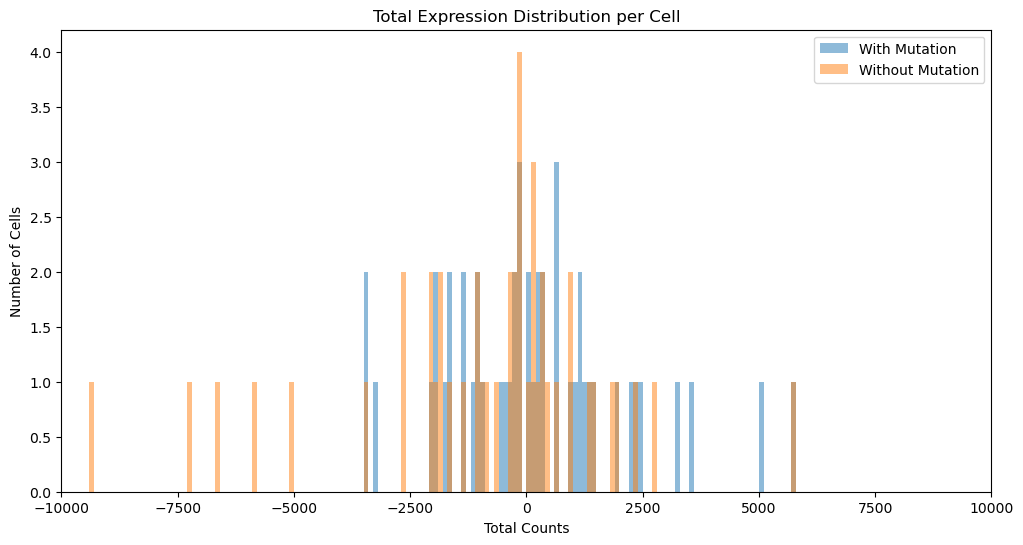

In [203]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume you have two dataframes: mutation_counts and no_mutation_counts
# Each dataframe contains scRNA-seq counts with cells as columns and genes as rows

# Calculate total counts per cell
mutation_total_counts = mutation_counts.obsm['X_pca'].sum(axis=0)
no_mutation_total_counts = no_mutation_counts.obsm['X_pca'].sum(axis=0)

# Define the range for the X-axis
x_min, x_max = -10000, 10000  # Example range, adjust based on your data

# Plot histograms
plt.figure(figsize=(12, 6))

# Histogram for cells with the mutation
plt.hist(mutation_total_counts, bins=200, alpha=0.5, range=(x_min, x_max), label='With Mutation')

# Histogram for cells without the mutation
plt.hist(no_mutation_total_counts, bins=200, alpha=0.5, range=(x_min, x_max), label='Without Mutation')

# Adding titles and labels
plt.title('Total Expression Distribution per Cell')
plt.xlabel('Total Counts')
plt.ylabel('Number of Cells')
plt.legend()

# Set the X-axis range
plt.xlim(x_min, x_max)

# Show the plot
plt.show()



In [204]:
print(mutation_counts.obsm['X_pca'])


[[-0.3915545  -0.25626713 -2.1844742  ...  1.4403601   0.20260523
  -0.27799472]
 [-4.3153744   0.03344763 -0.3623605  ...  0.1300242   0.6431034
   0.5276016 ]
 [ 1.4360111   5.6624937  -1.2260952  ...  2.0789046   0.12176634
   0.7892539 ]
 ...
 [-6.5029573  -1.9156286   2.6773245  ... -0.43866244  0.20655452
   0.6602577 ]
 [-5.2066917  -1.6930372   2.831259   ... -0.82587093  1.0188152
  -0.7802202 ]
 [-5.5420585  -2.0531368   4.485738   ... -1.3545353   0.9545377
  -0.9257854 ]]


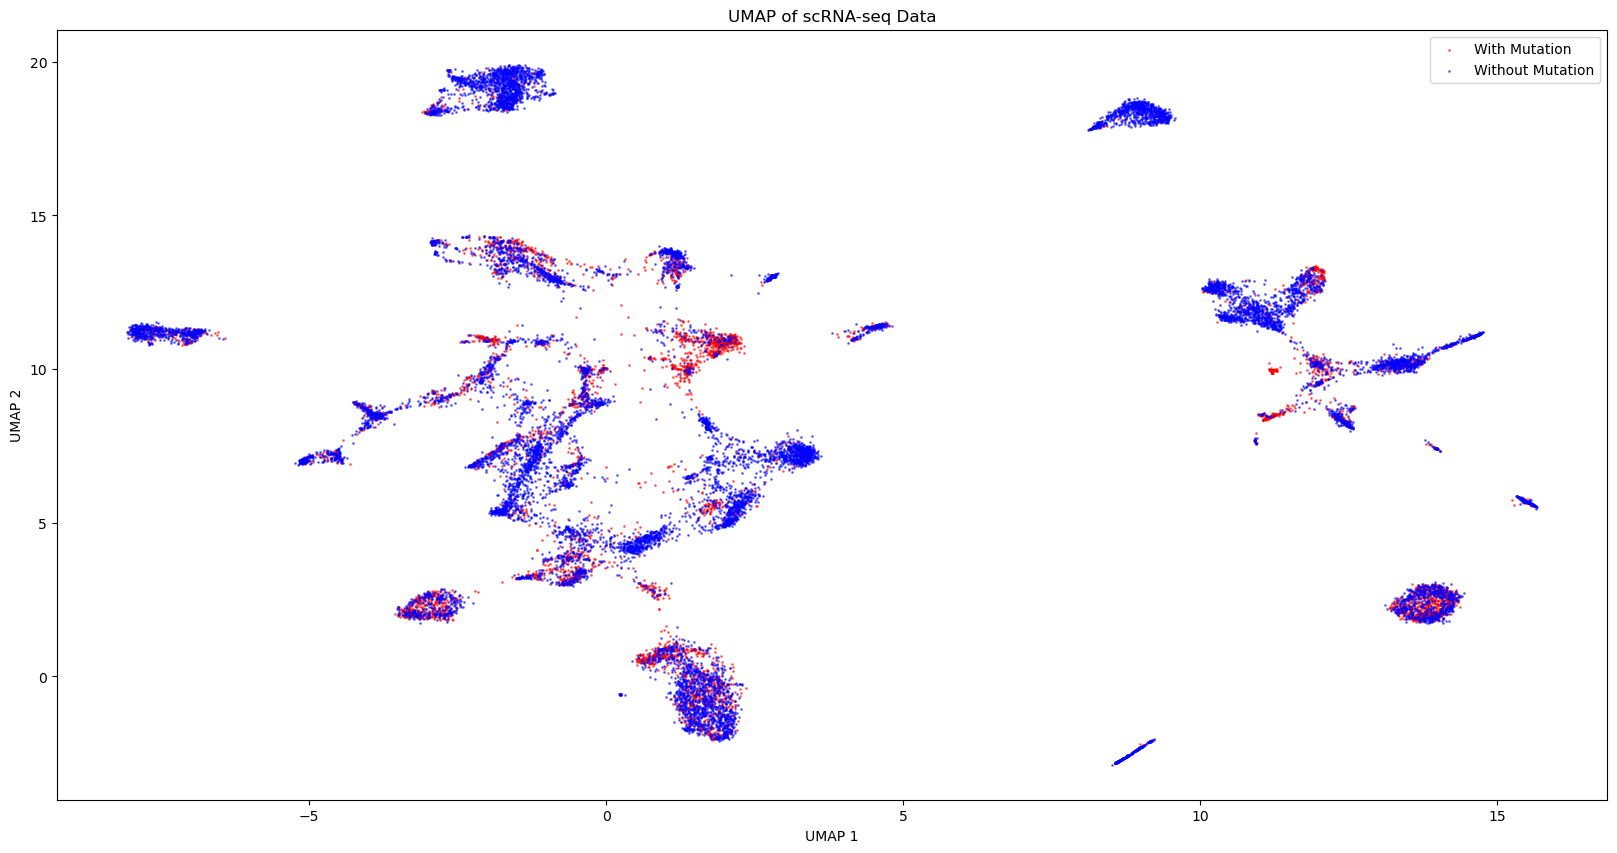

In [205]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume you have two AnnData objects: mutation_counts and no_mutation_counts

# Convert to pandas DataFrames
mutation_counts_df = pd.DataFrame(mutation_counts.obsm['X_pca'], index=mutation_counts.obs_names)
no_mutation_counts_df = pd.DataFrame(no_mutation_counts.obsm['X_pca'], index=no_mutation_counts.obs_names)

# Combine the datasets and create labels
combined_counts = pd.concat([mutation_counts_df, no_mutation_counts_df], axis=0)
labels = np.array(['With Mutation'] * mutation_counts_df.shape[0] + ['Without Mutation'] * no_mutation_counts_df.shape[0])

# Perform UMAP dimensionality reduction
reducer = umap.UMAP()
embedding = reducer.fit_transform(combined_counts)

# Plot UMAP
plt.figure(figsize=(20, 10))
plt.scatter(embedding[labels == 'With Mutation', 0], embedding[labels == 'With Mutation', 1], c='red', label='With Mutation', alpha=0.5, s=1)  # Smaller dots
plt.scatter(embedding[labels == 'Without Mutation', 0], embedding[labels == 'Without Mutation', 1], c='blue', label='Without Mutation', alpha=0.5, s=1)  # Smaller dots
plt.title('UMAP of scRNA-seq Data')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.show()



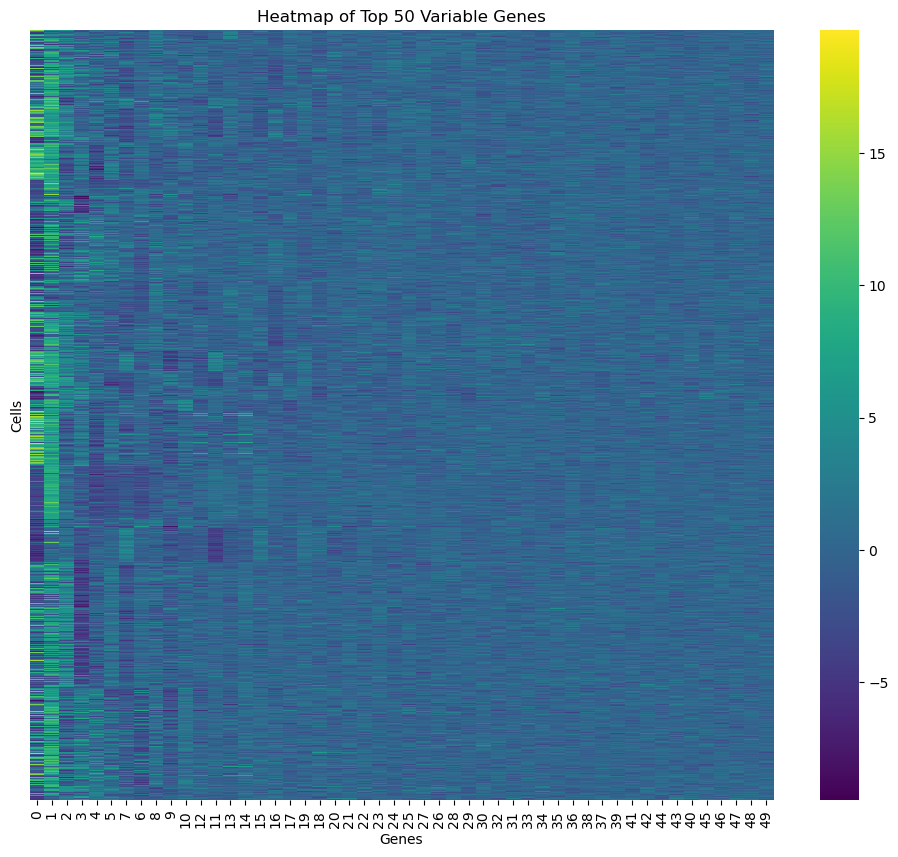

In [206]:
# Select the top variable genes for visualization
top_genes = combined_counts.var(axis=0).nlargest(200).index  # Top 50 variable genes

# Aggregate the expression data
mean_expression = combined_counts.loc[:, top_genes]

# Create labels again for the heatmap
heatmap_labels = pd.Series(labels, index=mean_expression.index, name='Group')

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mean_expression, cmap='viridis', yticklabels=False, cbar=True)
plt.title('Heatmap of Top 50 Variable Genes')
plt.xlabel('Genes')
plt.ylabel('Cells')
plt.show()



In [207]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

def filter_samples(adata, patient_id=None, sample_type=None):
    if patient_id:
        # Filter for specific AML patient
        filtered_adata = adata[adata.obs.index.str.startswith(patient_id)]
    elif sample_type == 'BM':
        # Filter for healthy bone marrow samples
        filtered_adata = adata[adata.obs.index.str.startswith('BM')]
    else:
        # Return the original adata if no filter is applied
        filtered_adata = adata
    return filtered_adata

def plot_mutation_distribution(filtered_adata):
    # List of mutations and classifiers
    mutations = [
        'TET2', 'NPM1', 'WT1', 'DNMT3A', 'SRSF2', 'KRAS', 'IDH2', 'BCOR', 'FLT3', 
        'CEBPA', 'SF3B1', 'RUNX1', 'IDH1', 'PHF6', 'NF1', 'JAK2', 'NRAS', 'CCND3', 
        'RAD21', 'ASXL1', 'CREBBP', 'BCORL1', 'EZH2', 'STAG2', 'PTPN11', 'U2AF1', 
        'TP53', 'GATA2', 'ZRSR2', 'KIT', 'PDS5B', 'SMC1A', 'CBL', 'SMC3'
    ]
    classifiers = ['ridge', 'rf', 'svm']

    # Create a DataFrame to store the count of predictions for each mutation and classifier
    data = {mutation: {classifier: 0 for classifier in classifiers} for mutation in mutations}

    # Count occurrences of each prediction
    for mutation in mutations:
        for classifier in classifiers:
            pred_col = f'{classifier}_preds_{mutation}'
            data[mutation][classifier] = filtered_adata.obs[pred_col].sum()

    # Convert to a DataFrame
    df = pd.DataFrame(data).T

    # Plotting the data
    df.plot(kind='bar', figsize=(15, 8), width=0.8)
    plt.title('Distribution of Gene Mutations with Overlapped Predictions from Classifiers')
    plt.xlabel('Gene Mutation')
    plt.ylabel('Number of Predicted Mutations')
    plt.xticks(rotation=90)
    plt.legend(title='Classifier')
    plt.tight_layout()
    plt.show()



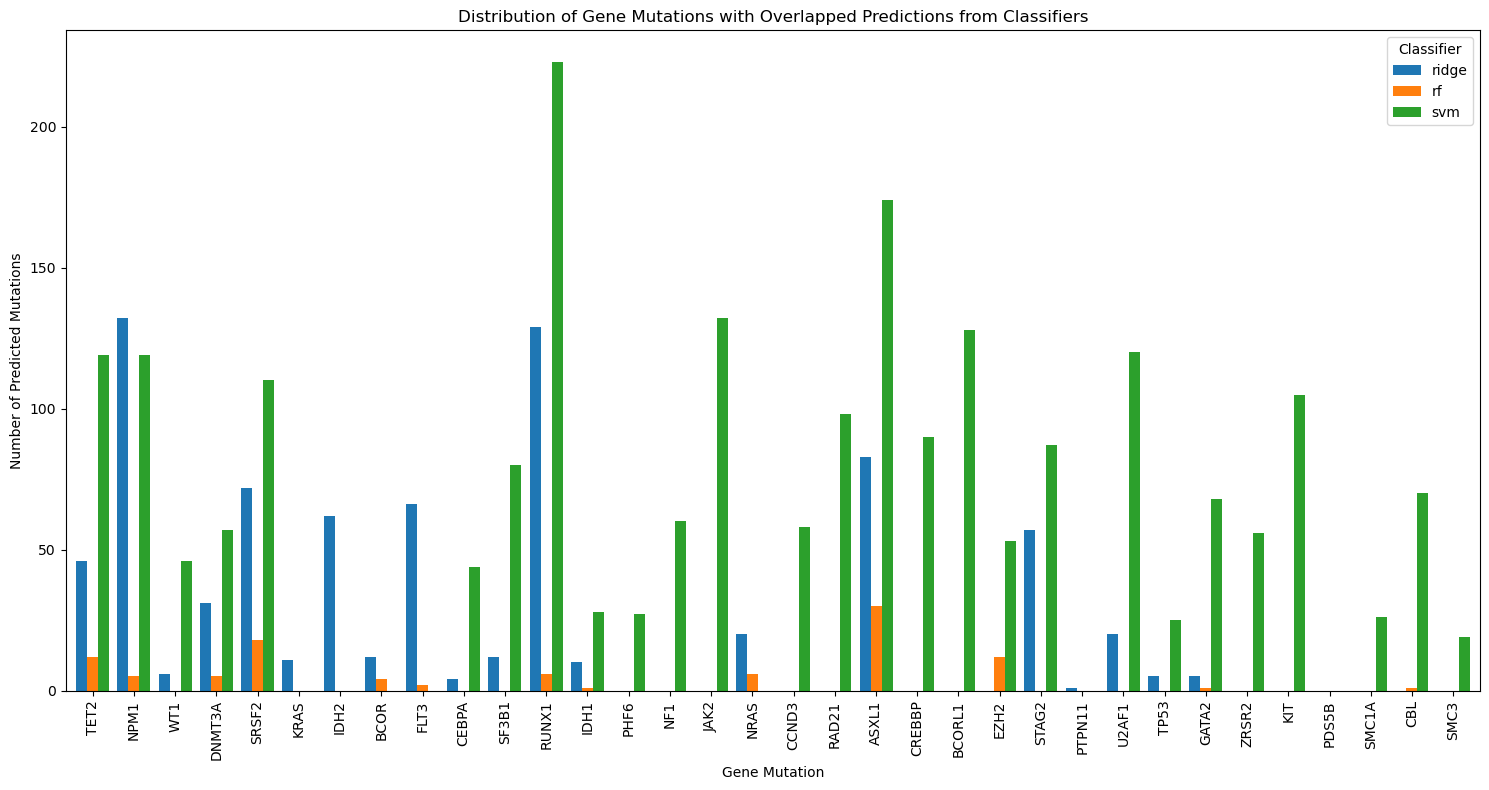

In [208]:
# Example usage
# Replace `scrna_preds_adata` with your AnnData object variable name
#patient_id = 'AML1012'  # Replace with the specific patient ID you want to filter
#patient_id = 'AML210A'
#patient_id = 'AML419A'
patient_id = 'AML475'
#sample_type = 'BM'  # Replace with 'BM' to filter healthy bone marrow samples

# Filter the data
filtered_adata = filter_samples(scrna_preds_adata, patient_id=patient_id)
# Plot the mutation distribution for the filtered data
plot_mutation_distribution(filtered_adata)


In [209]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

def filter_samples(adata, patient_id=None, sample_type=None):
    if patient_id:
        # Filter for specific AML patient
        filtered_adata = adata[adata.obs.index.str.startswith(patient_id)]
    elif sample_type == 'BM':
        # Filter for healthy bone marrow samples
        filtered_adata = adata[adata.obs.index.str.startswith('BM')]
    else:
        # Return the original adata if no filter is applied
        filtered_adata = adata
    return filtered_adata

def calculate_mutation_percentages(filtered_adata):
    # List of mutations and classifiers
    mutations = [
        'TET2', 'NPM1', 'WT1', 'DNMT3A', 'SRSF2', 'KRAS', 'IDH2', 'BCOR', 'FLT3', 
        'CEBPA', 'SF3B1', 'RUNX1', 'IDH1', 'PHF6', 'NF1', 'JAK2', 'NRAS', 'CCND3', 
        'RAD21', 'ASXL1', 'CREBBP', 'BCORL1', 'EZH2', 'STAG2', 'PTPN11', 'U2AF1', 
        'TP53', 'GATA2', 'ZRSR2', 'KIT', 'PDS5B', 'SMC1A', 'CBL', 'SMC3'
    ]
    classifiers = ['ridge', 'rf', 'svm']

    # Create a DataFrame to store the percentage of predictions for each mutation and classifier
    data = {mutation: {classifier: 0 for classifier in classifiers} for mutation in mutations}

    # Calculate total number of cells
    total_cells = filtered_adata.shape[0]

    # Calculate percentages of each prediction
    for mutation in mutations:
        for classifier in classifiers:
            pred_col = f'{classifier}_preds_{mutation}'
            positive_cells = filtered_adata.obs[pred_col].sum()
            percentage = (positive_cells / total_cells) * 100
            data[mutation][classifier] = percentage

    # Convert to a DataFrame
    df = pd.DataFrame(data).T

    return df

def plot_mutation_percentages(df):
    # Plotting the data
    df.plot(kind='bar', figsize=(15, 8), width=0.8)
    plt.title('Percentage of Cells with Specific Gene Mutations by Classifier')
    plt.xlabel('Gene Mutation')
    plt.ylabel('Percentage of Cells (%)')
    plt.xticks(rotation=90)
    plt.legend(title='Classifier')
    plt.tight_layout()
    plt.show()



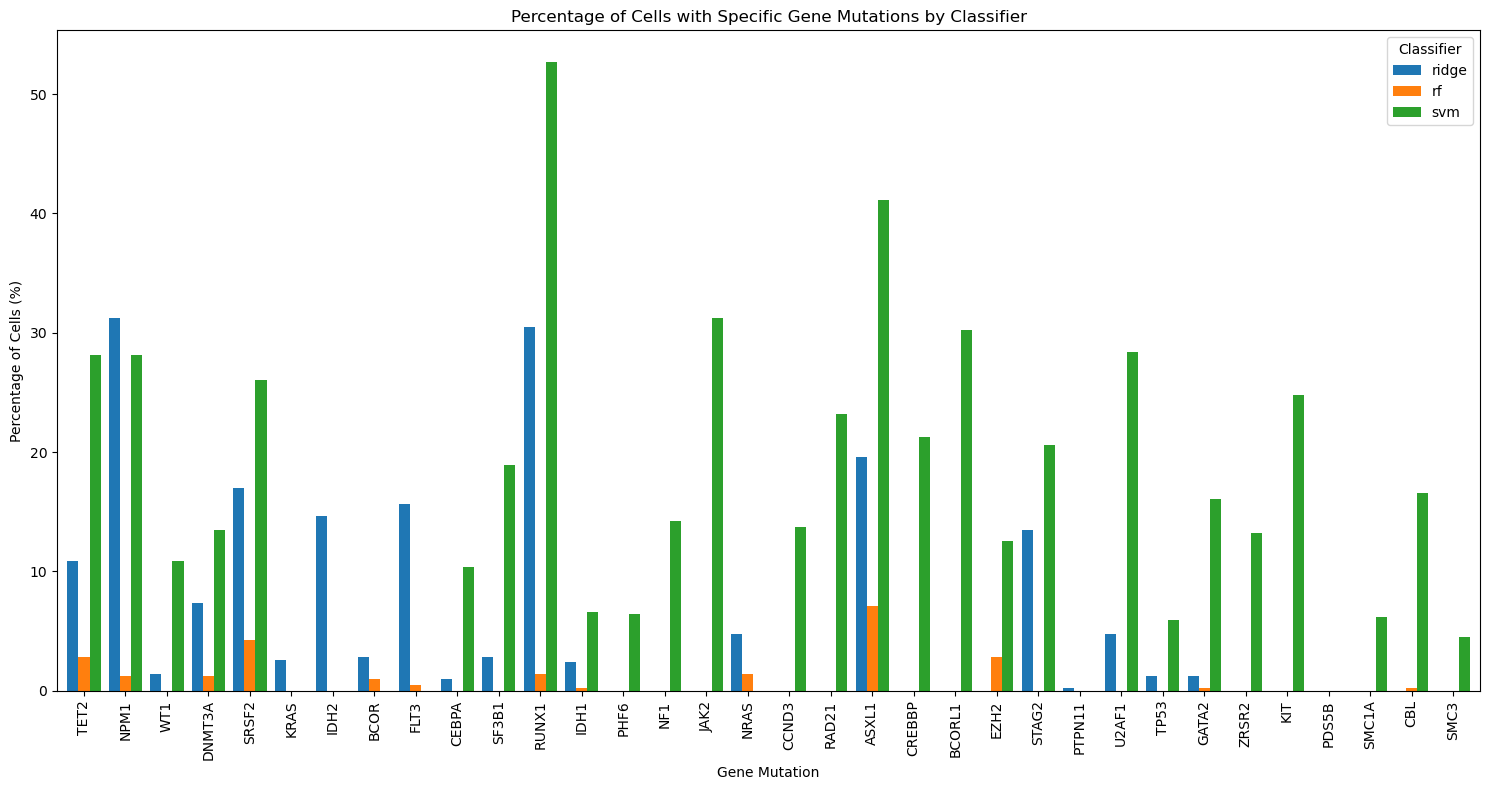

In [210]:
# Example usage
# Replace `scrna_preds_adata` with your AnnData object variable name
#patient_id = 'AML1012'  # Replace with the specific patient ID you want to filter
#patient_id = 'AML210A'
#patient_id = 'AML419A'
patient_id = 'AML475'
#sample_type = 'BM'  # Replace with 'BM' to filter healthy bone marrow samples

# Filter the data
filtered_adata = filter_samples(scrna_preds_adata, patient_id=patient_id)
# Calculate the mutation percentages for the filtered data
mutation_percentages_df = calculate_mutation_percentages(filtered_adata)
# Plot the mutation percentages
plot_mutation_percentages(mutation_percentages_df)



In [211]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

def filter_samples(adata, patient_id=None, sample_type=None):
    if patient_id:
        # Filter for specific AML patient
        filtered_adata = adata[adata.obs.index.str.startswith(patient_id)]
    elif sample_type == 'BM':
        # Filter for healthy bone marrow samples
        filtered_adata = adata[adata.obs.index.str.startswith('BM')]
    else:
        # Return the original adata if no filter is applied
        filtered_adata = adata
    return filtered_adata

def calculate_consensus_mutation_counts(filtered_adata):
    # List of mutations
    mutations = [
        'TET2', 'NPM1', 'WT1', 'DNMT3A', 'SRSF2', 'KRAS', 'IDH2', 'BCOR', 'FLT3', 
        'CEBPA', 'SF3B1', 'RUNX1', 'IDH1', 'PHF6', 'NF1', 'JAK2', 'NRAS', 'CCND3', 
        'RAD21', 'ASXL1', 'CREBBP', 'BCORL1', 'EZH2', 'STAG2', 'PTPN11', 'U2AF1', 
        'TP53', 'GATA2', 'ZRSR2', 'KIT', 'PDS5B', 'SMC1A', 'CBL', 'SMC3'
    ]
    classifiers = ['ridge', 'rf', 'svm']

    # Create a dictionary to store the counts of predictions for each mutation where all classifiers agree
    data = {mutation: 0 for mutation in mutations}

    # Calculate counts of each prediction
    for mutation in mutations:
        ridge_col = f'ridge_preds_{mutation}'
        rf_col = f'rf_preds_{mutation}'
        svm_col = f'svm_preds_{mutation}'
        
        # Only count cells where all three classifiers predicted the mutation
        common_predictions = filtered_adata.obs[
            (filtered_adata.obs[ridge_col] == 1) &
            (filtered_adata.obs[rf_col] == 1) &
            (filtered_adata.obs[svm_col] == 1)
        ].shape[0]
        
        data[mutation] = common_predictions

    # Convert to a DataFrame
    df = pd.DataFrame.from_dict(data, orient='index', columns=['Count'])

    return df

def plot_consensus_mutation_counts(df):
    # Plotting the data
    df.plot(kind='bar', figsize=(15, 8), width=0.8, legend=False)
    plt.title('Total Counts of Cells with Consensus Gene Mutations')
    plt.xlabel('Gene Mutation')
    plt.ylabel('Total Counts of Cells')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


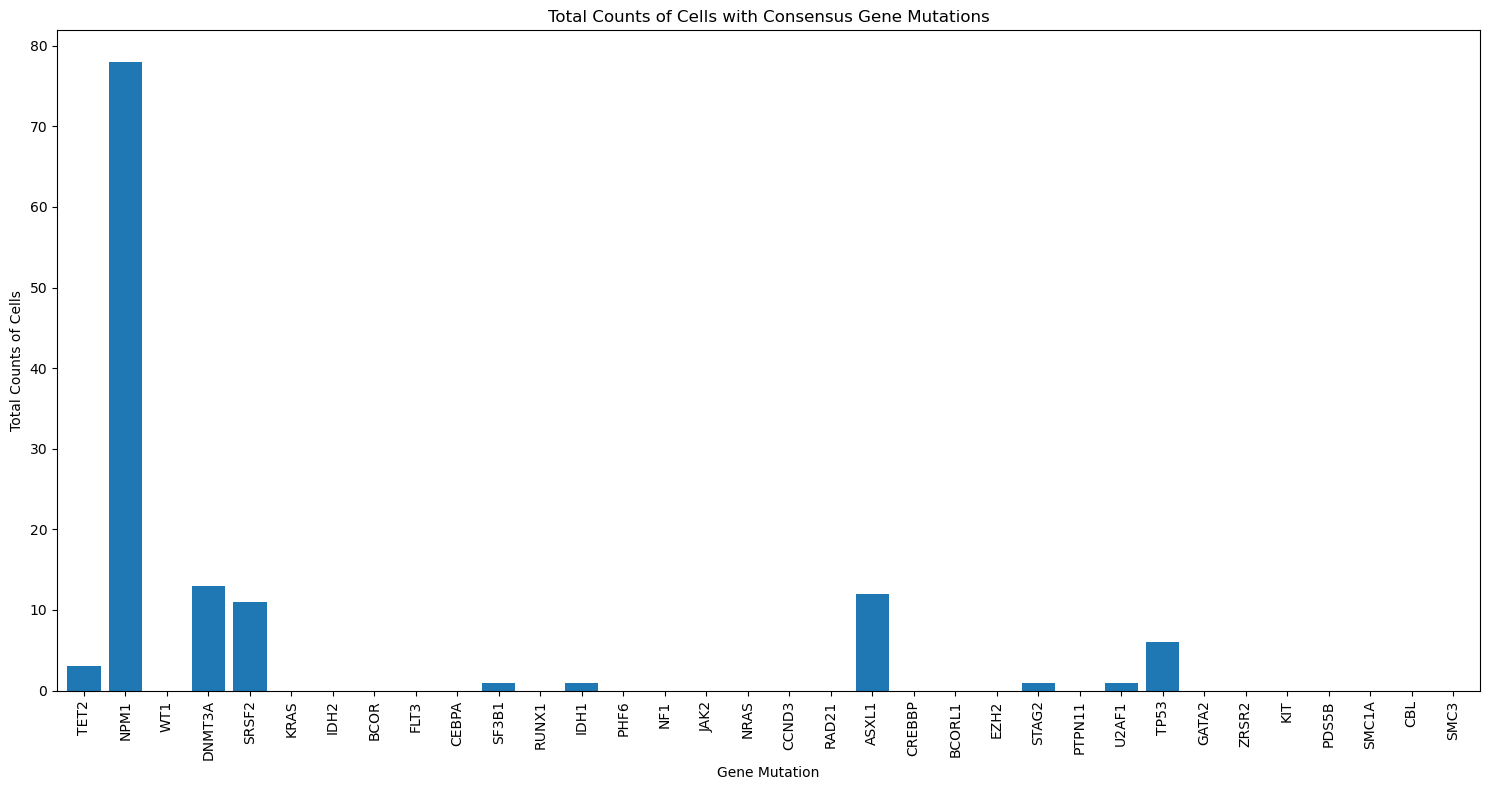

In [212]:
# Replace `scrna_preds_adata` with your AnnData object variable name
patient_id = 'AML210A'  # Replace with the specific patient ID you want to filter
#sample_type = 'BM'  # Replace with 'BM' to filter healthy bone marrow samples

# Filter the data
filtered_adata = filter_samples(scrna_preds_adata, patient_id=patient_id)
# Calculate the consensus mutation counts for the filtered data
consensus_mutation_counts_df = calculate_consensus_mutation_counts(filtered_adata)
# Plot the consensus mutation counts
plot_consensus_mutation_counts(consensus_mutation_counts_df)


In [213]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

def filter_samples(adata, patient_id=None, sample_type=None):
    if patient_id:
        # Filter for specific AML patient
        filtered_adata = adata[adata.obs.index.str.startswith(patient_id)]
    elif sample_type == 'BM':
        # Filter for healthy bone marrow samples
        filtered_adata = adata[adata.obs.index.str.startswith('BM')]
    else:
        # Return the original adata if no filter is applied
        filtered_adata = adata
    return filtered_adata

def calculate_consensus_mutation_percentages(filtered_adata):
    # List of mutations
    mutations = [
        'TET2', 'NPM1', 'WT1', 'DNMT3A', 'SRSF2', 'KRAS', 'IDH2', 'BCOR', 'FLT3', 
        'CEBPA', 'SF3B1', 'RUNX1', 'IDH1', 'PHF6', 'NF1', 'JAK2', 'NRAS', 'CCND3', 
        'RAD21', 'ASXL1', 'CREBBP', 'BCORL1', 'EZH2', 'STAG2', 'PTPN11', 'U2AF1', 
        'TP53', 'GATA2', 'ZRSR2', 'KIT', 'PDS5B', 'SMC1A', 'CBL', 'SMC3'
    ]

    # Create a dictionary to store the percentages of predictions for each mutation where all classifiers agree
    data = {mutation: 0 for mutation in mutations}

    # Calculate total number of cells
    total_cells = filtered_adata.shape[0]

    # Calculate percentages of each prediction
    for mutation in mutations:
        ridge_col = f'ridge_preds_{mutation}'
        rf_col = f'rf_preds_{mutation}'
        svm_col = f'svm_preds_{mutation}'
        
        # Only count cells where all three classifiers predicted the mutation
        common_predictions = filtered_adata.obs[
            (filtered_adata.obs[ridge_col] == 1) &
            (filtered_adata.obs[rf_col] == 1) &
            (filtered_adata.obs[svm_col] == 1)
        ].shape[0]
        
        percentage = (common_predictions / total_cells) * 100
        data[mutation] = percentage

    # Convert to a DataFrame
    df = pd.DataFrame.from_dict(data, orient='index', columns=['Percentage'])

    return df

def plot_consensus_mutation_percentages(df):
    # Plotting the data
    df.plot(kind='bar', figsize=(15, 8), width=0.8, legend=False)
    plt.title('Percentage of Cells with Consensus Gene Mutations')
    plt.xlabel('Gene Mutation')
    plt.ylabel('Percentage of Cells (%)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


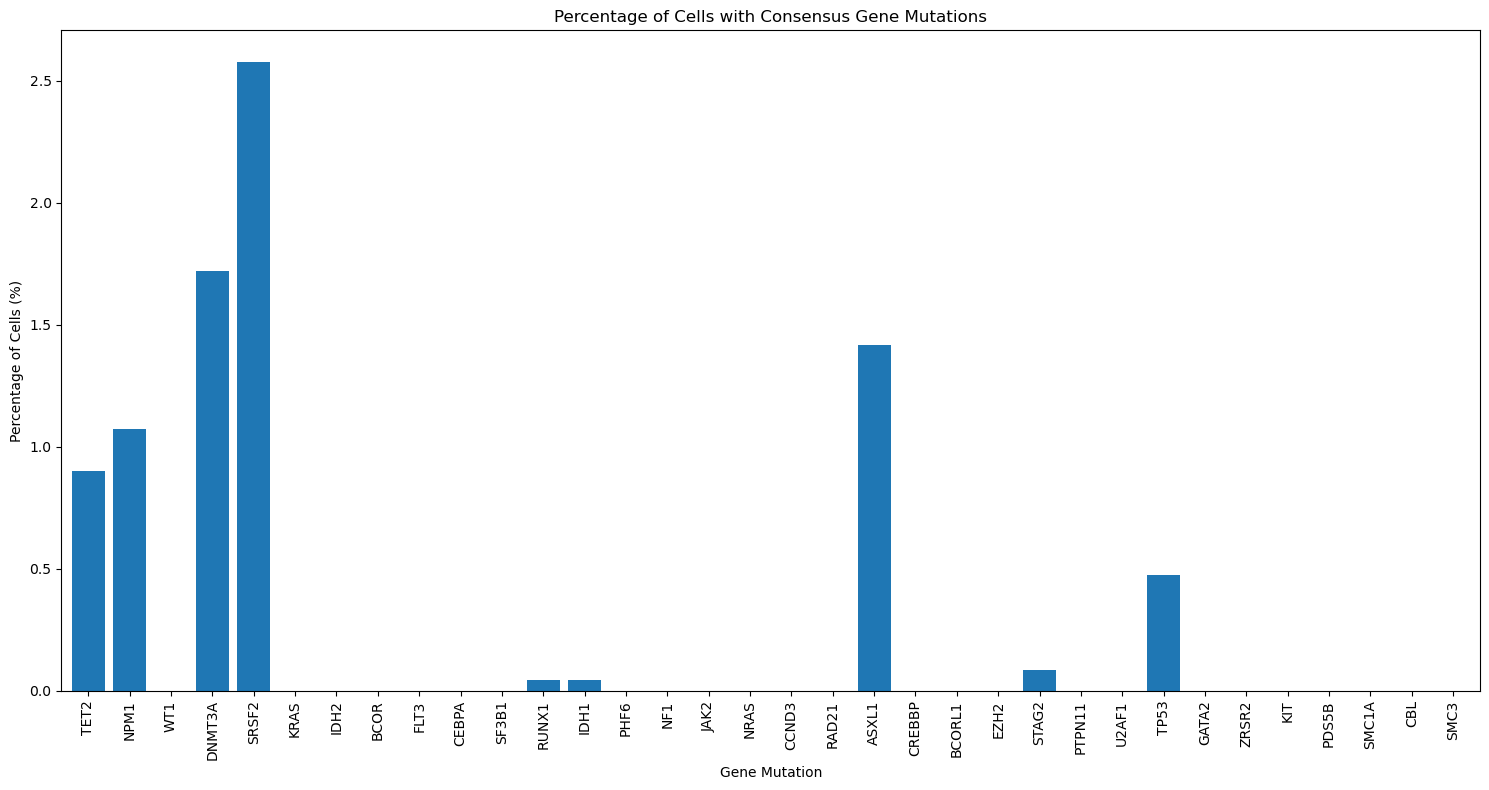

In [214]:
# Replace `scrna_preds_adata` with your AnnData object variable name
patient_id = 'AML556'  # Replace with the specific patient ID you want to filter
#sample_type = 'BM'  # Replace with 'BM' to filter healthy bone marrow samples

# Filter the data
filtered_adata = filter_samples(scrna_preds_adata, patient_id=patient_id)
# Calculate the consensus mutation percentages for the filtered data
consensus_mutation_percentages_df = calculate_consensus_mutation_percentages(filtered_adata)
# Plot the consensus mutation percentages
plot_consensus_mutation_percentages(consensus_mutation_percentages_df)


In [215]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

def filter_samples(adata, patient_id=None, sample_type=None):
    if patient_id:
        # Filter for specific AML patient
        filtered_adata = adata[adata.obs.index.str.startswith(patient_id)]
    elif sample_type == 'BM':
        # Filter for healthy bone marrow samples
        filtered_adata = adata[adata.obs.index.str.startswith('BM')]
    else:
        # Return the original adata if no filter is applied
        filtered_adata = adata
    return filtered_adata

def calculate_consensus_mutation_percentages(filtered_adata):
    # List of mutations
    mutations = [
        'TET2', 'NPM1', 'WT1', 'DNMT3A', 'SRSF2', 'KRAS', 'IDH2', 'BCOR', 'FLT3', 
        'CEBPA', 'SF3B1', 'RUNX1', 'IDH1', 'PHF6', 'NF1', 'JAK2', 'NRAS', 'CCND3', 
        'RAD21', 'ASXL1', 'CREBBP', 'BCORL1', 'EZH2', 'STAG2', 'PTPN11', 'U2AF1', 
        'TP53', 'GATA2', 'ZRSR2', 'KIT', 'PDS5B', 'SMC1A', 'CBL', 'SMC3'
    ]

    # Create a dictionary to store the percentages of predictions for each mutation where at least two classifiers agree
    data = {mutation: 0 for mutation in mutations}

    # Calculate total number of cells
    total_cells = filtered_adata.shape[0]

    # Calculate percentages of each prediction
    for mutation in mutations:
        ridge_col = f'ridge_preds_{mutation}'
        rf_col = f'rf_preds_{mutation}'
        svm_col = f'svm_preds_{mutation}'

        # Count cells where at least two classifiers predicted the mutation
        agreement_predictions = filtered_adata.obs[
            ((filtered_adata.obs[ridge_col] == 1) & (filtered_adata.obs[rf_col] == 1)) |
            ((filtered_adata.obs[ridge_col] == 1) & (filtered_adata.obs[svm_col] == 1)) |
            ((filtered_adata.obs[rf_col] == 1) & (filtered_adata.obs[svm_col] == 1))
        ].shape[0]

        percentage = (agreement_predictions / total_cells) * 100
        data[mutation] = percentage

    # Convert to a DataFrame
    df = pd.DataFrame.from_dict(data, orient='index', columns=['Percentage'])

    return df

def plot_consensus_mutation_percentages(df):
    # Plotting the data
    df.plot(kind='bar', figsize=(15, 8), width=0.8, legend=False)
    plt.title('Percentage of Cells with Consensus Gene Mutations (At Least Two Classifiers Agree)')
    plt.xlabel('Gene Mutation')
    plt.ylabel('Percentage of Cells (%)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()



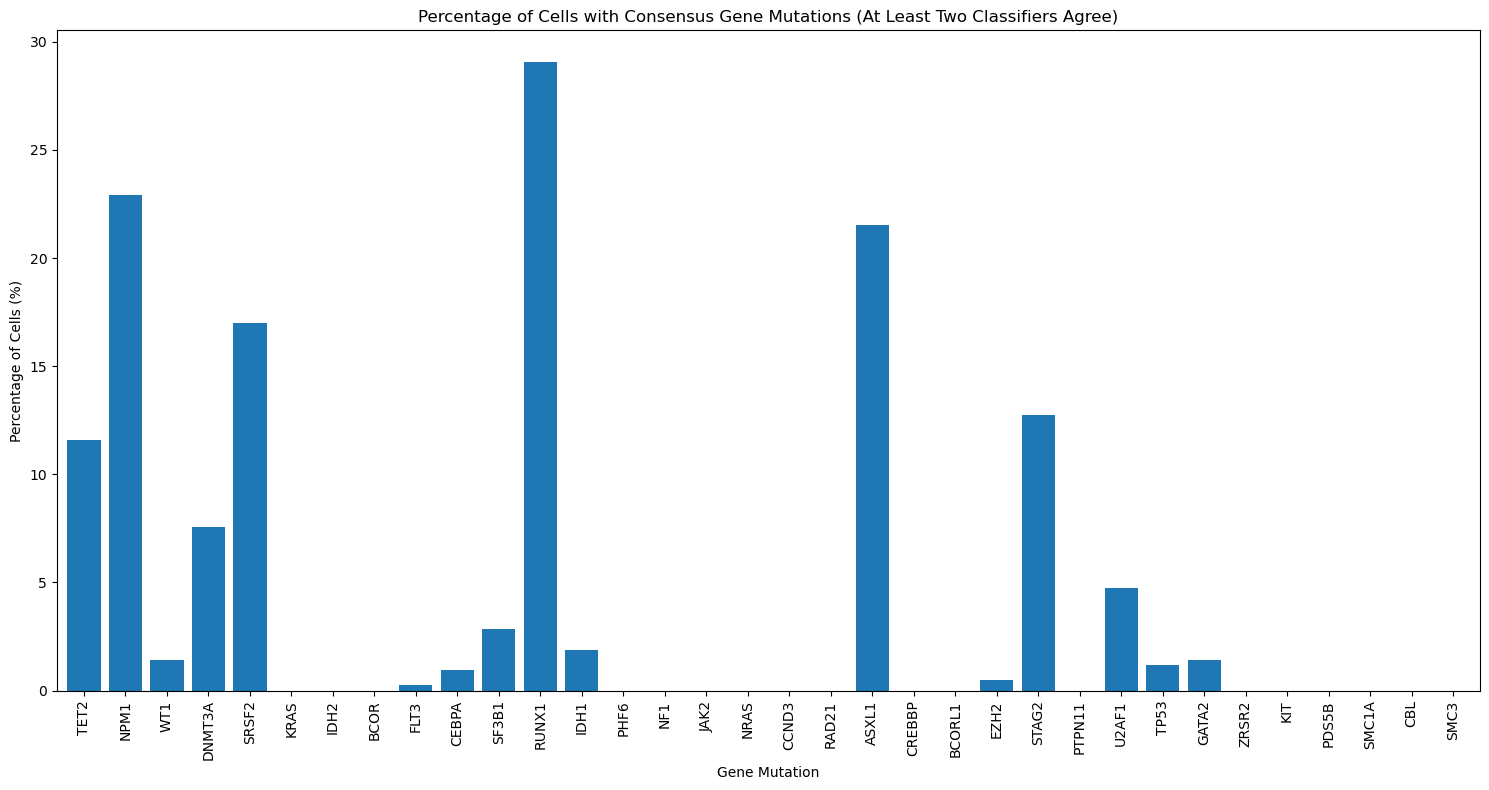

In [216]:
# Replace `scrna_preds_adata` with your AnnData object variable name
patient_id = 'AML475'  # Replace with the specific patient ID you want to filter
#sample_type = 'BM'  # Replace with 'BM' to filter healthy bone marrow samples

# Filter the data
filtered_adata = filter_samples(scrna_preds_adata, patient_id=patient_id)
# Calculate the consensus mutation percentages for the filtered data
consensus_mutation_percentages_df = calculate_consensus_mutation_percentages(filtered_adata)
# Plot the consensus mutation percentages
plot_consensus_mutation_percentages(consensus_mutation_percentages_df)

